The objective of this project is to build a machine learning classification model that predicts whether an e-commerce customer will churn based on their demographic information and behavioral activity.

Import Required Libraries



In [3]:
# Data handling libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

Load the Dataset


In [4]:
# Load the dataset
df=pd.read_csv("/content/ecommerece.zip")

In [5]:
# Preview the data
df

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,38.0,Female,USA,Los Angeles,10.0,10.0,35.8,8.8,51.2,3.0,...,9.2,5.0,1.0,20.7,25.2,1.0,2365.98,3499.0,0,Q2
49996,37.0,Male,USA,Chicago,1.4,21.0,32.4,9.6,32.5,2.0,...,17.6,5.0,3.0,38.6,12.1,4.0,1293.60,3154.0,0,Q3
49997,44.0,Female,USA,Phoenix,2.8,19.0,40.3,10.4,50.6,1.0,...,25.2,4.0,6.0,59.9,NaN,1.0,1655.28,1622.0,0,Q1
49998,41.0,Female,USA,Chicago,2.9,17.0,29.9,10.1,60.8,1.0,...,34.6,5.0,2.0,NaN,14.1,3.0,1286.11,2634.0,0,Q2


Data Cleaning

In [6]:
# Check dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [7]:
# Provides statistical summary of numerical features
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,...,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,...,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,...,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,...,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.817500,1049.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,...,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,41.000000,...,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1874.000000,2791.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,...,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000


In [8]:
# Shows dataset dimensions (rows, columns)
df.shape

(50000, 25)

Target Variable Analysis

In [9]:
df['Churned'].value_counts(normalize=True) * 100


,proportion
Churned,
0,71.1
1,28.9


Visualization


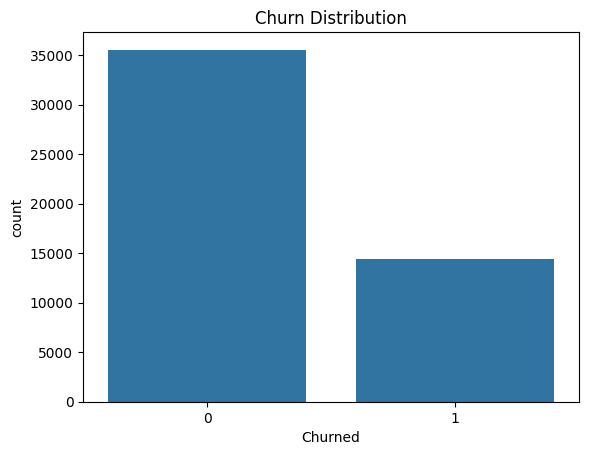

In [10]:
sns.countplot(x='Churned', data=df)
plt.title("Churn Distribution")
plt.show()


Handle Missing Values



In [11]:
# Check missing values
df.isnull().sum()/len(df)*100


,0
Age,4.990
Gender,0.000
Country,0.000
City,0.000
Membership_Years,0.000
Login_Frequency,0.000
Session_Duration_Avg,6.798
Pages_Per_Session,6.000
Cart_Abandonment_Rate,0.000
Wishlist_Items,8.000


In [12]:
# Removing the dupplicates values
df.duplicated().sum()

np.int64(0)

In [13]:
# counts the each row and columns
df.value_counts()

Age    Gender  Country    City         Membership_Years  Login_Frequency  Session_Duration_Avg  Pages_Per_Session  Cart_Abandonment_Rate  Wishlist_Items  Total_Purchases  Average_Order_Value  Days_Since_Last_Purchase  Discount_Usage_Rate  Returns_Rate  Email_Open_Rate  Customer_Service_Calls  Product_Reviews_Written  Social_Media_Engagement_Score  Mobile_App_Usage  Payment_Method_Diversity  Lifetime_Value  Credit_Balance  Churned  Signup_Quarter
200.0  Male    UK         Leeds        2.6               4.0              13.1                  3.7                86.4                   0.0             7.8              50.77                6.0                       29.76                7.6           8.4              7.0                     0.0                      0.0                            4.5               2.0                       266.08          0.0             1        Q4                1
5.0    Female  Canada     Calgary      4.0               7.0              15.7                  2.1                61.8                   2.0             15.0             304.53               1.0                       31.00                5.7           0.0              9.0                     0.0                      15.9                           15.2              3.0                       4207.03         0.0             1        Q3                1
               Germany    Cologne      0.3               12.0             34.8                  9.1                53.2                   8.0             11.0             98.12                7.0                       50.00                12.9          31.4             3.0                     5.0                      22.3                           18.0              2.0                       1023.44         2157.0          0        Q2                1
               USA        Los Angeles  0.9               27.0             51.6                  14.6               30.1                   13.0            21.0             239.17               15.0                      45.40                5.7           36.8             3.0                     1.0                      63.0                           30.1              5.0                       4941.02         2717.0          1        Q2                1
       Male    USA        Los Angeles  7.8               14.0             22.7                  12.3               54.3                   6.0             12.0             68.77                93.0                      79.50                8.1           19.7             8.0                     2.0                      25.3                           26.5              2.0                       940.42          1473.0          0        Q1                1
                                                                                                                                                                                                                                                                                                                                                                                                                                                                    ..
18.0   Female  Australia  Brisbane     1.9               20.0             62.7                  12.8               9.2                    10.0            23.0             108.00               67.0                      27.10                1.6           38.0             2.0                     11.0                     66.2                           41.7              2.0                       2079.67         2392.0          1        Q1                1
                                                         17.0             46.2                  16.2               41.4                   7.0             26.0             85.20                4.0                       39.24                1.6           15.3             4.0                     3.0                      49.7                           36.2           

<Axes: >

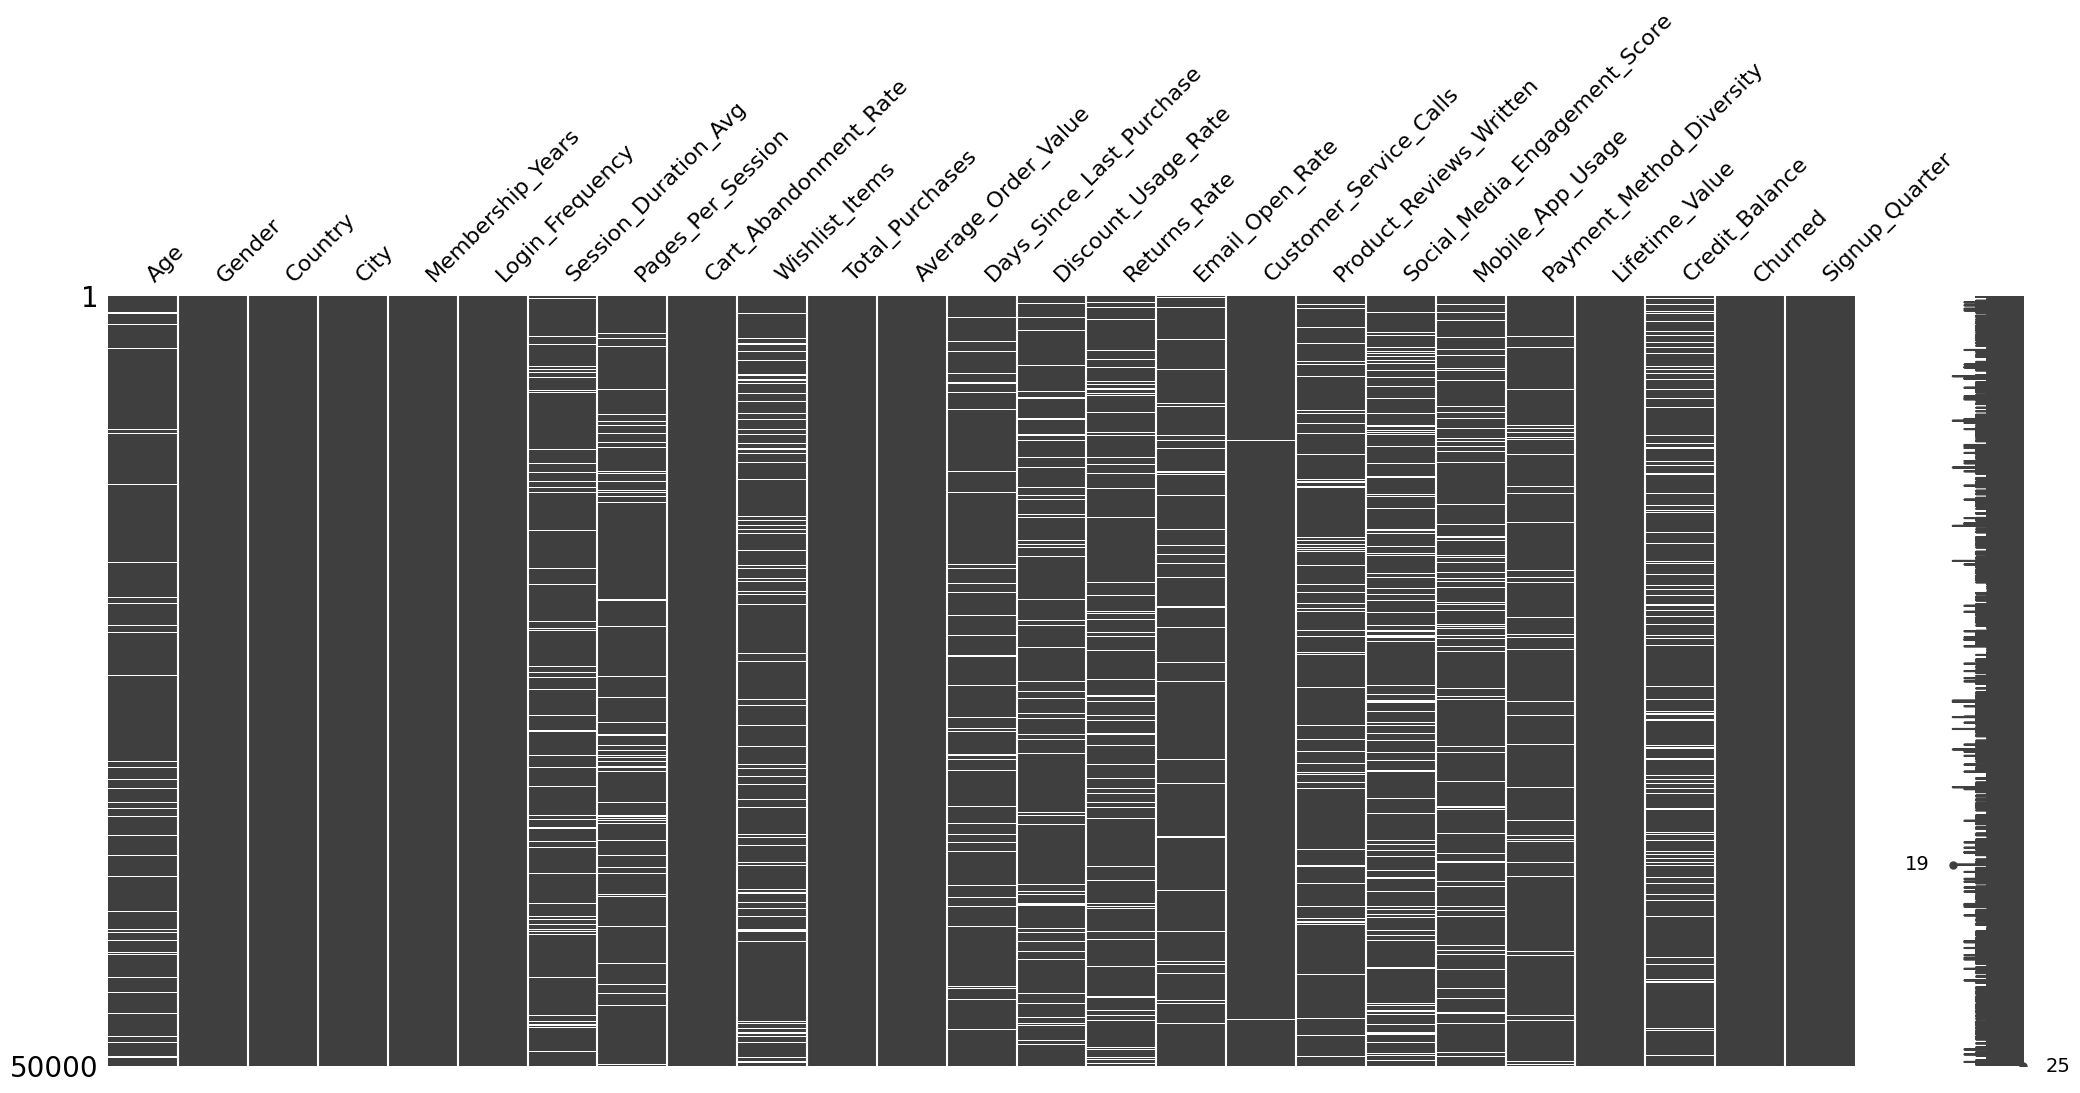

In [14]:
# Visualizes missing values in the dataset using a matrix plot
import missingno as msn
msn.matrix(df)

In [15]:
# Drop columns with low predictive importance
columns_to_drop = ["City", "Signup_Quarter", "Country"]
df = df.drop(columns=columns_to_drop, errors='ignore')

Age


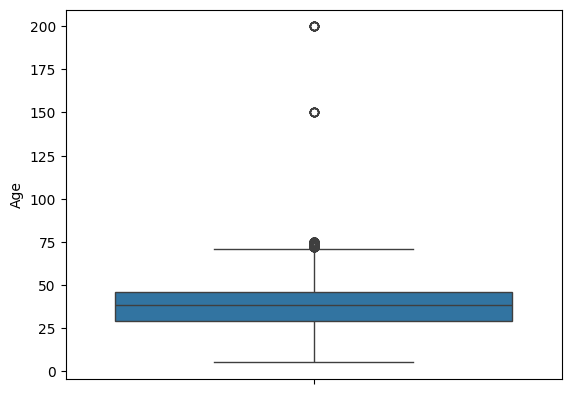

Gender


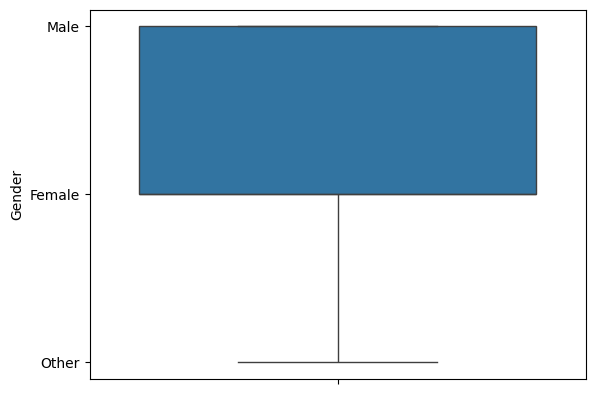

Membership_Years


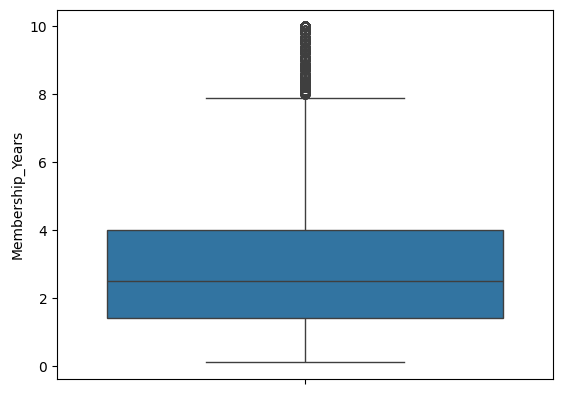

Login_Frequency


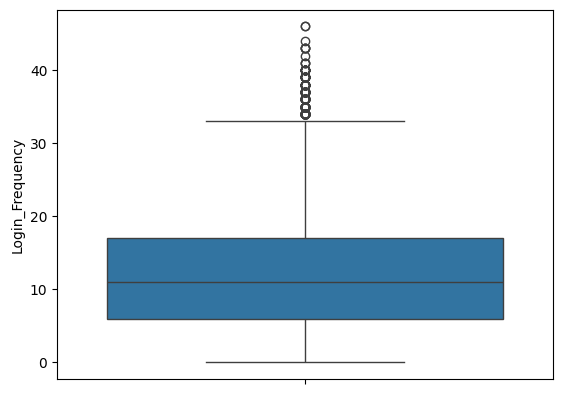

Session_Duration_Avg


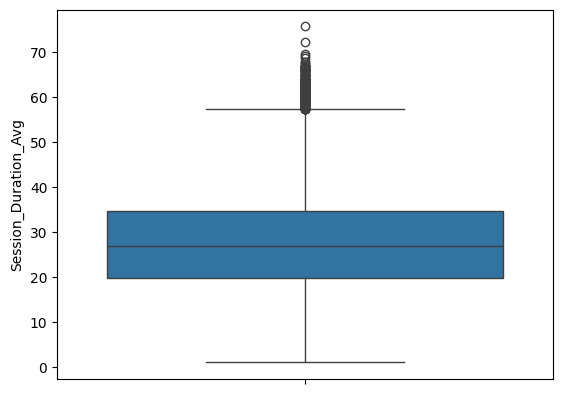

Pages_Per_Session


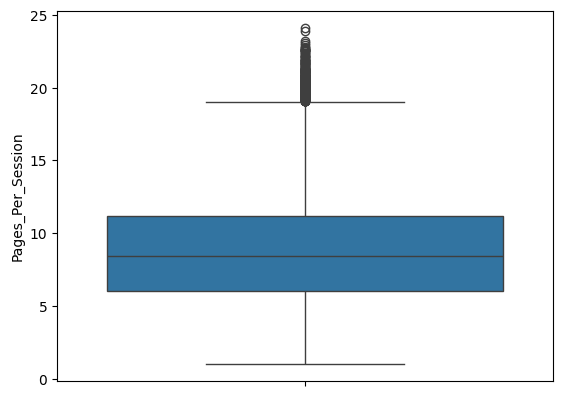

Cart_Abandonment_Rate


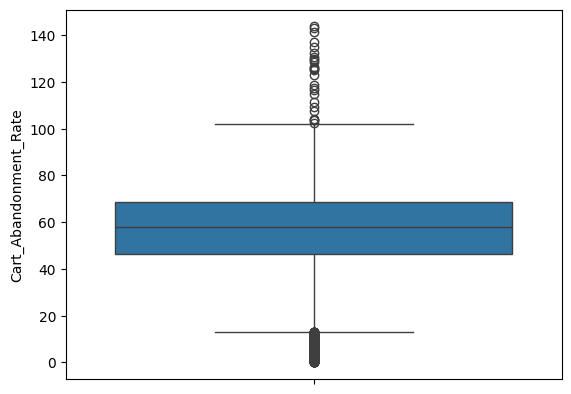

Wishlist_Items


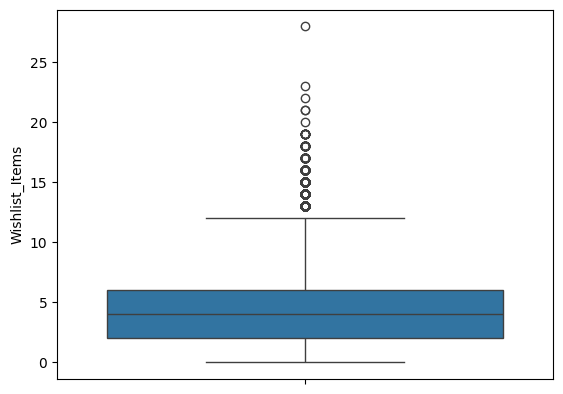

Total_Purchases


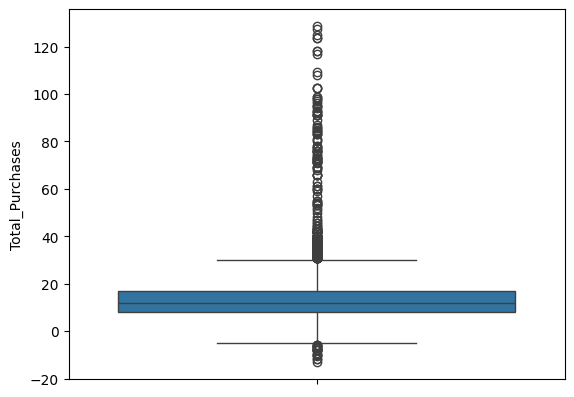

Average_Order_Value


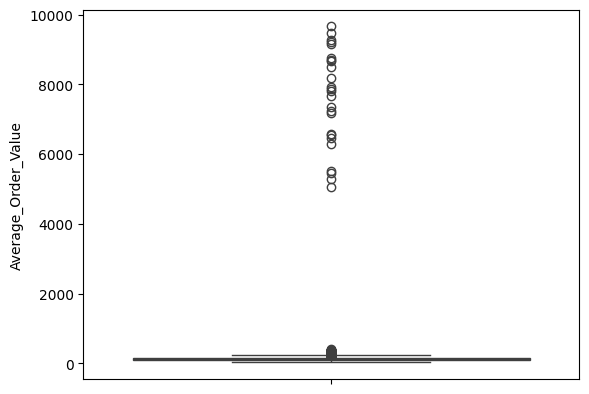

Days_Since_Last_Purchase


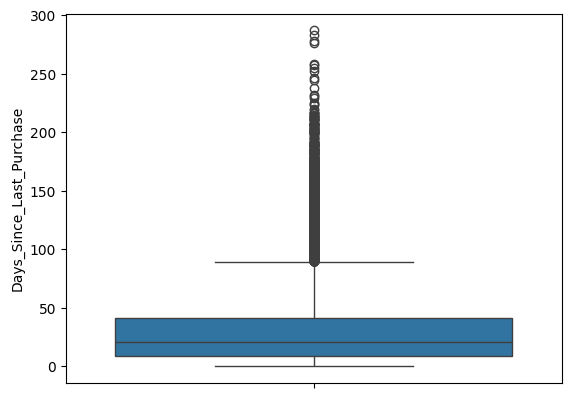

Discount_Usage_Rate


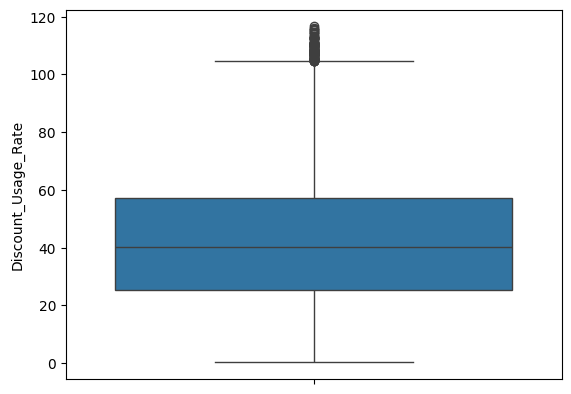

Returns_Rate


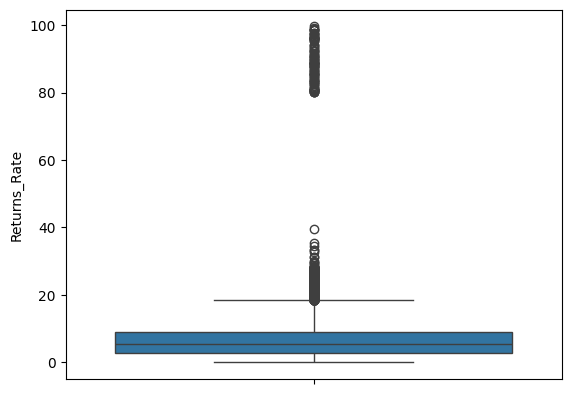

Email_Open_Rate


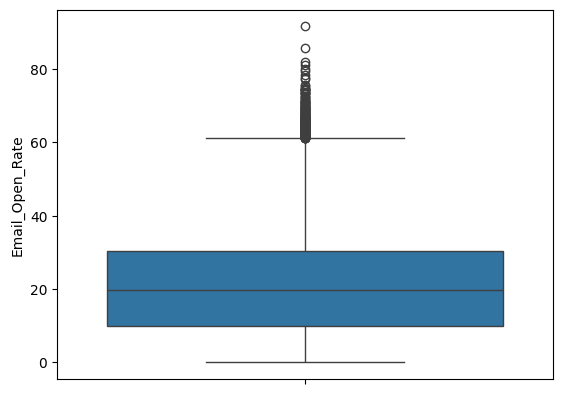

Customer_Service_Calls


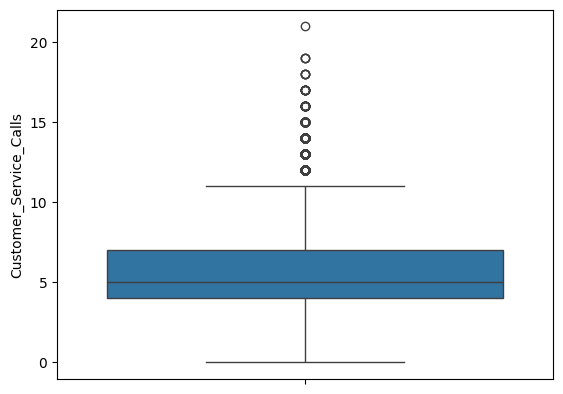

Product_Reviews_Written


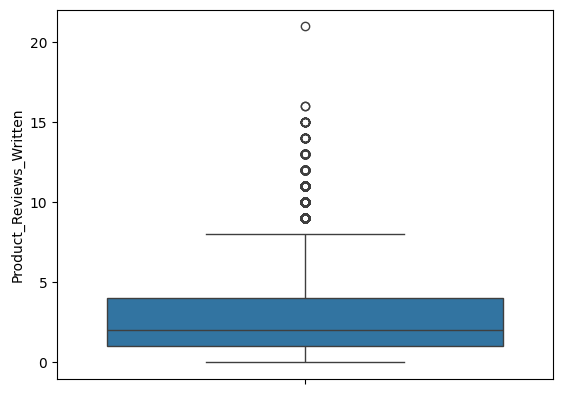

Social_Media_Engagement_Score


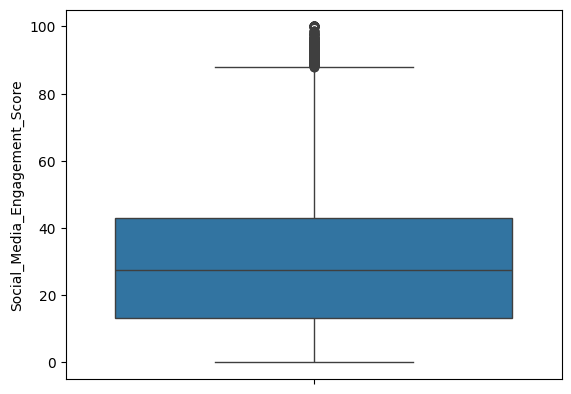

Mobile_App_Usage


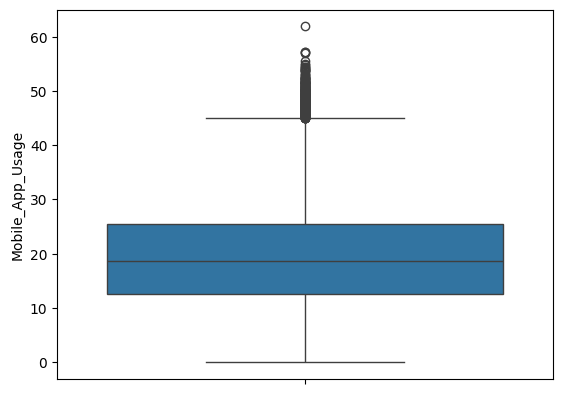

Payment_Method_Diversity


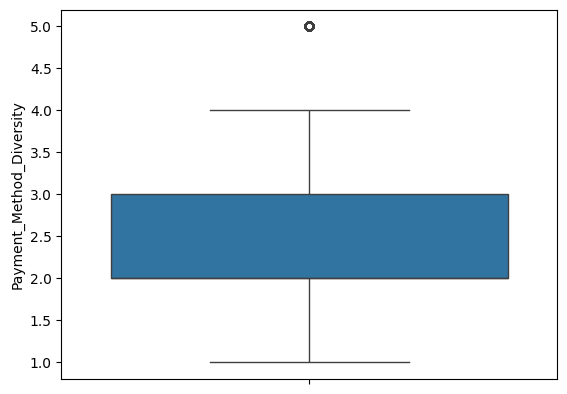

Lifetime_Value


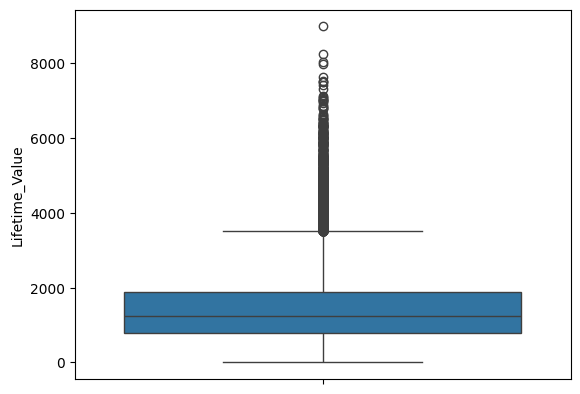

Credit_Balance


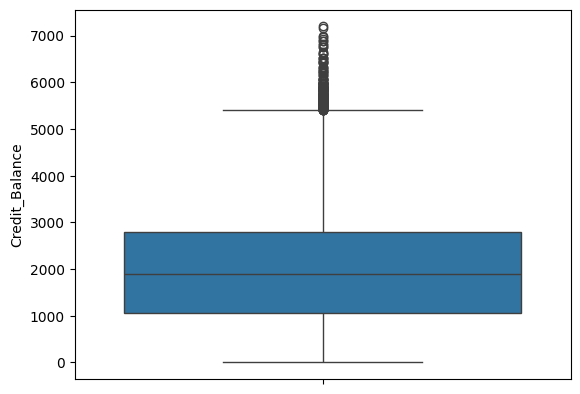

Churned


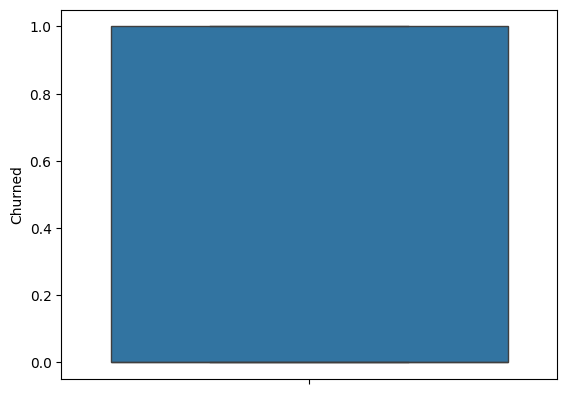

In [16]:
# Visualizes outliers for each column using boxplots
for i in df.columns:
    print(i)
    sns.boxplot(df[i])
    plt.show()

In [17]:
# Numerical columns → fill with median
num_cols = df.select_dtypes(include=["float64", "int64"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical column → fill with mode
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])


Numerical Feature Analysis

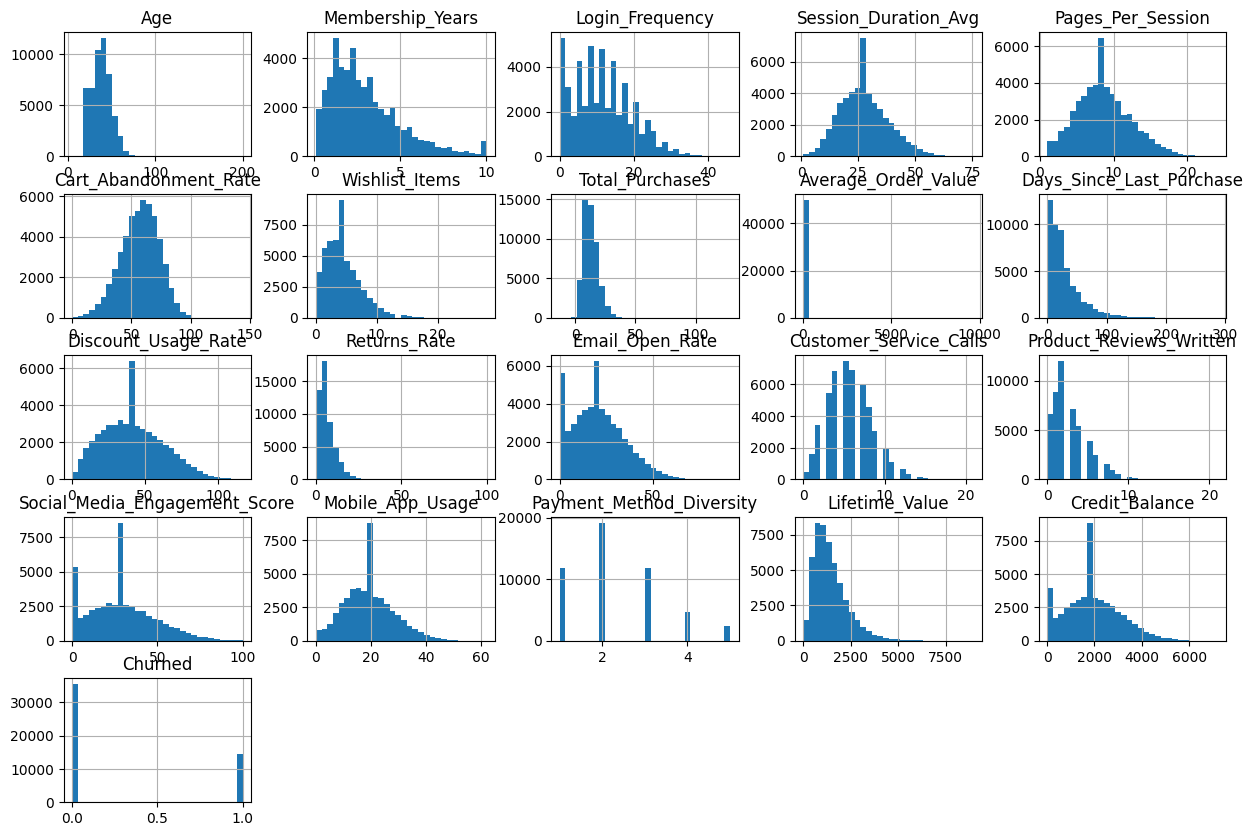

In [18]:
df[num_cols].hist(figsize=(15,10), bins=30)
plt.show()

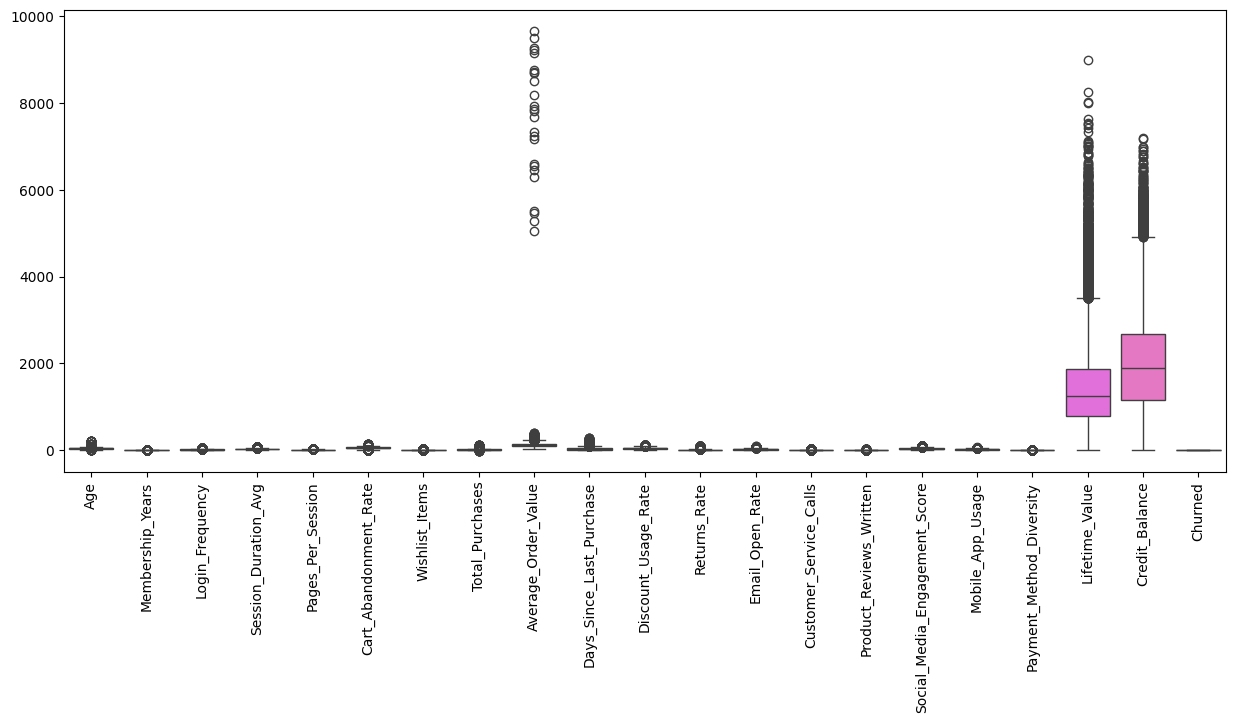

In [19]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.show()

Categorical Feature Analysis

In [20]:
#Value Counts
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    print("\n", col)
    print(df[col].value_counts().head())


 Gender
Gender
Female    25116
Male      23947
Other       937
Name: count, dtype: int64


Churn vs Categorical Features

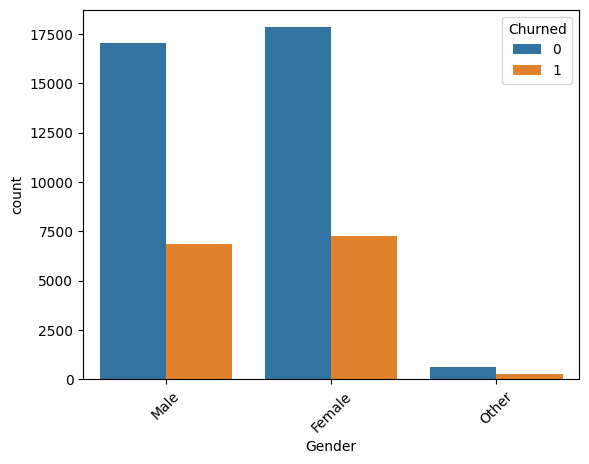

In [21]:
for col in cat_cols:
    sns.countplot(x=col, hue='Churned', data=df)
    plt.xticks(rotation=45)
    plt.show()

#Insight:
#Shows which categories have higher churn
#Important for business interpretation


Correlation Analysis (Numerical Only)

In [22]:
#Correlation Matrix
corr = df[num_cols].corr()


Heatmap
Purpose:

Detect multicollinearity

Understand feature relationships

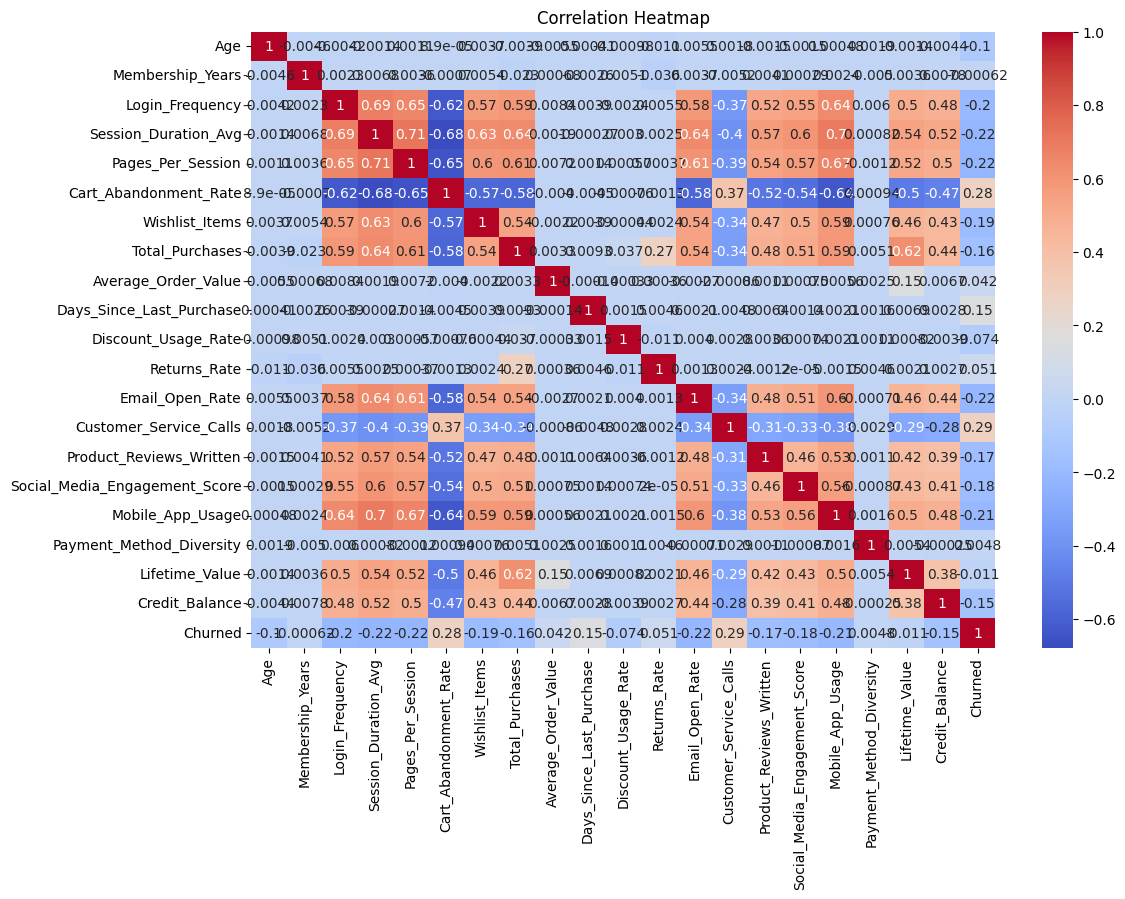

In [23]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Churn vs Numerical Features

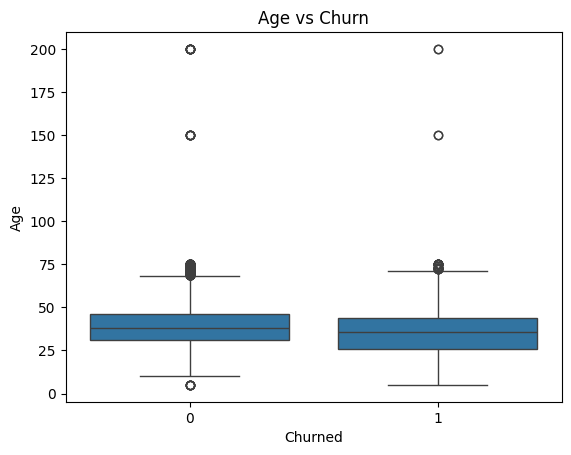

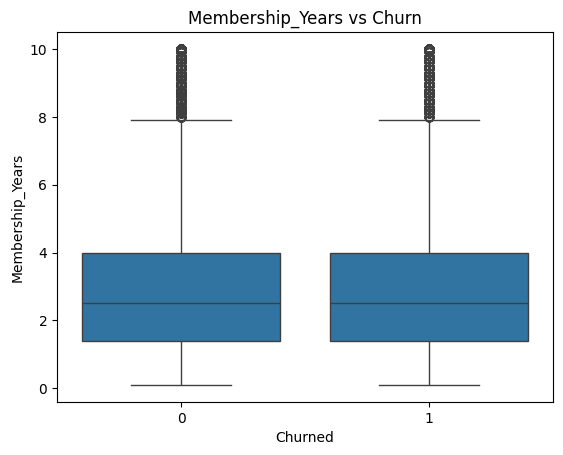

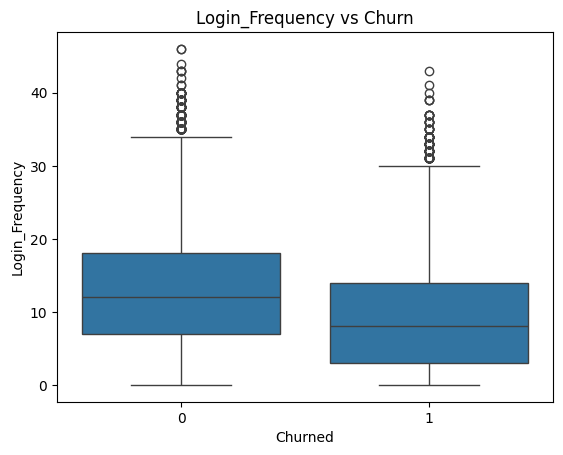

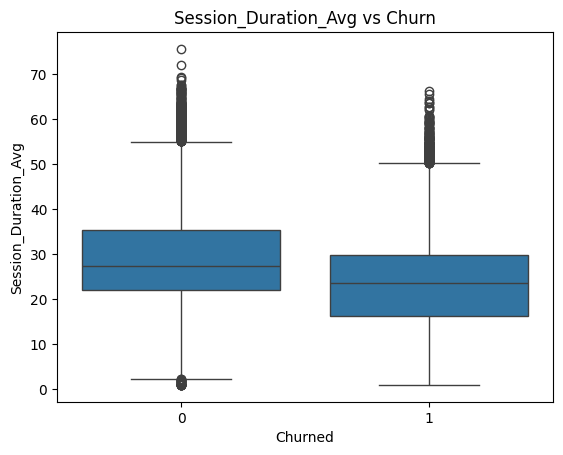

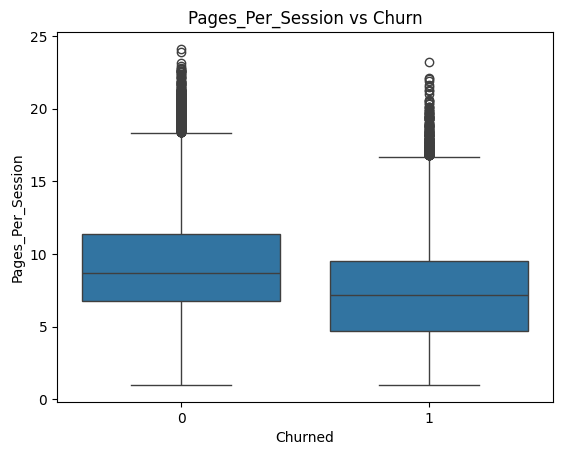

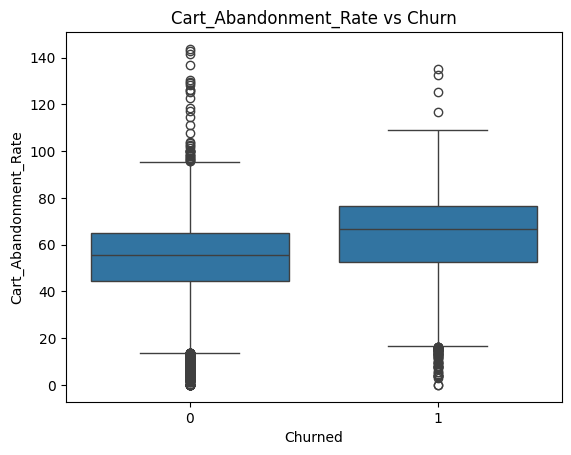

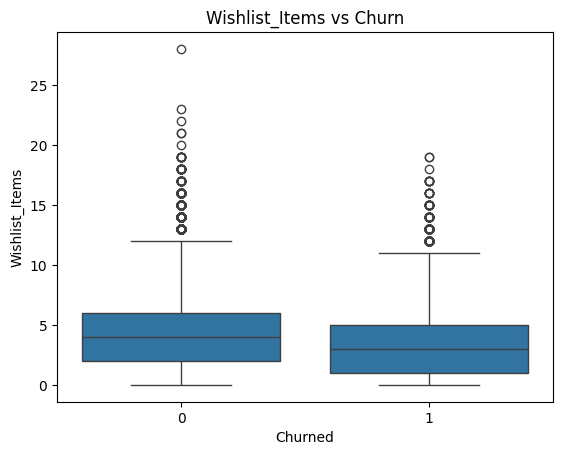

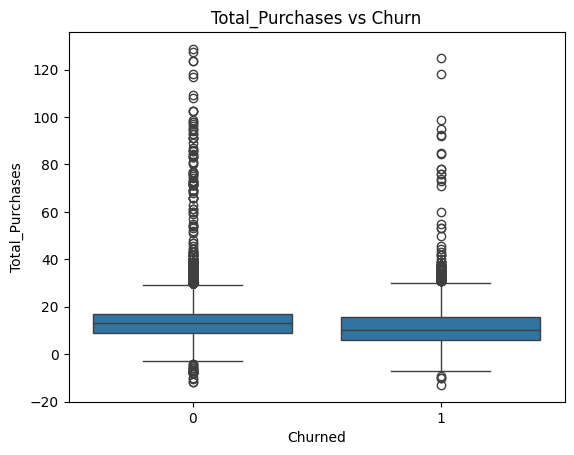

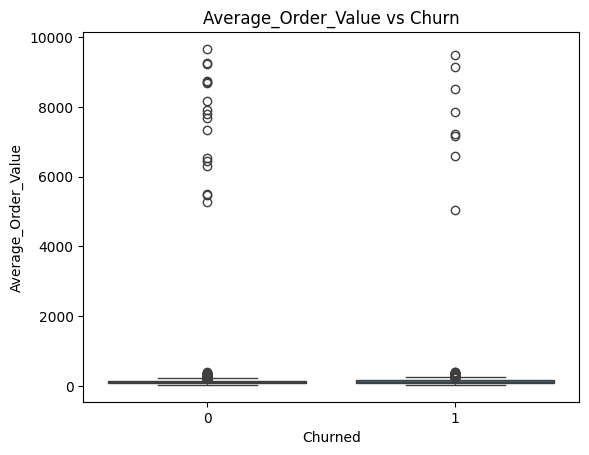

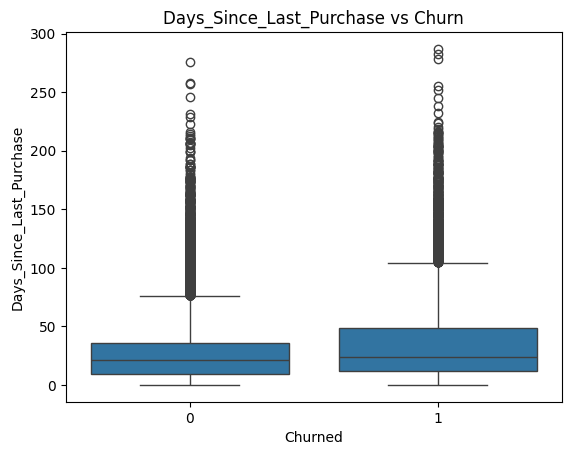

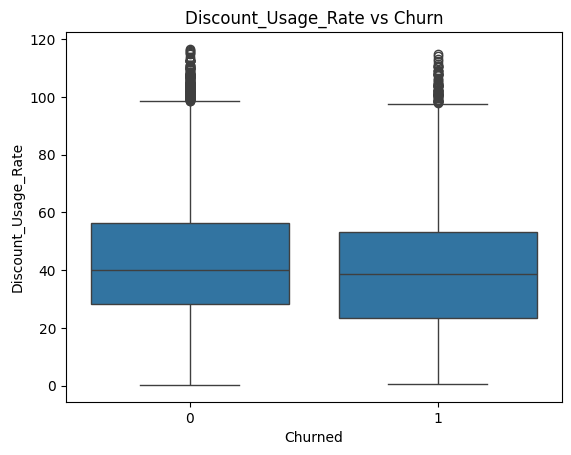

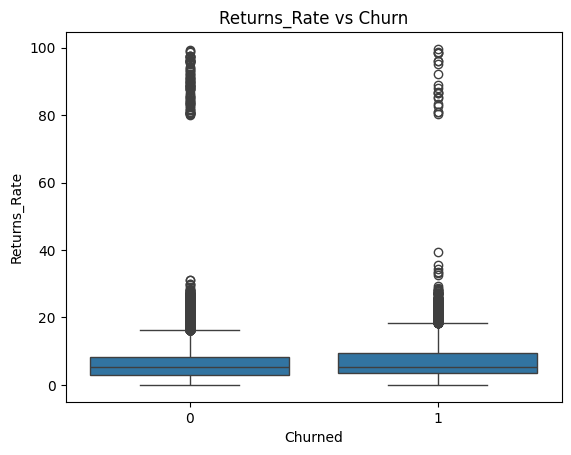

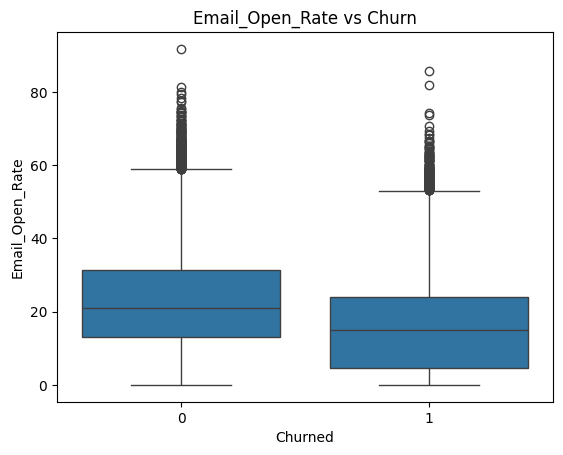

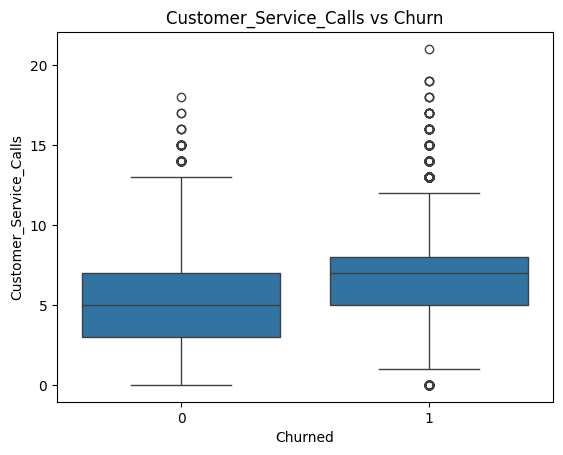

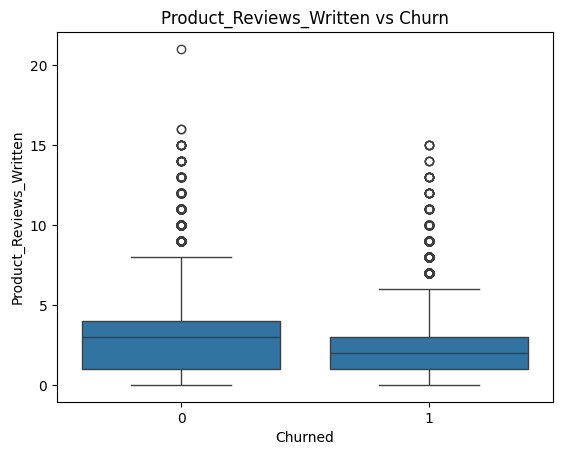

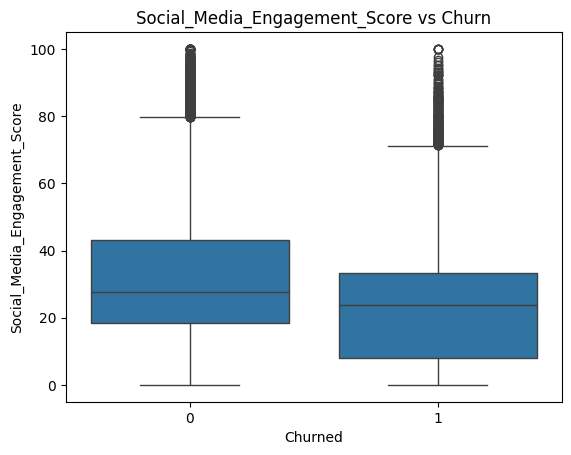

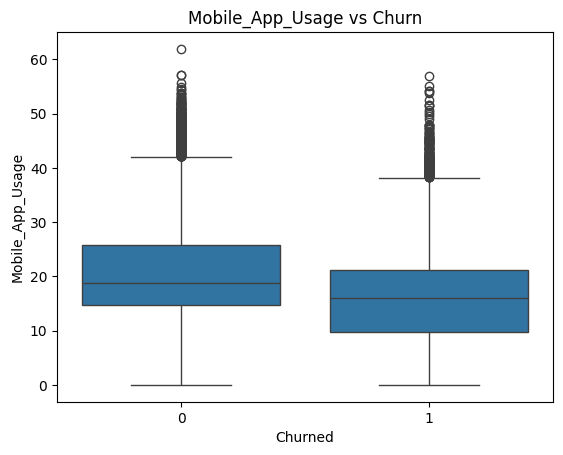

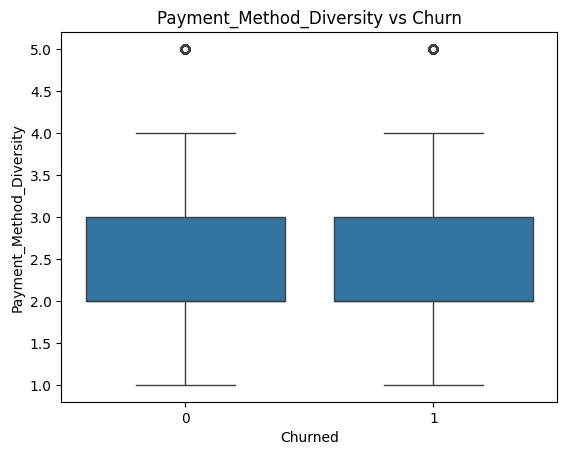

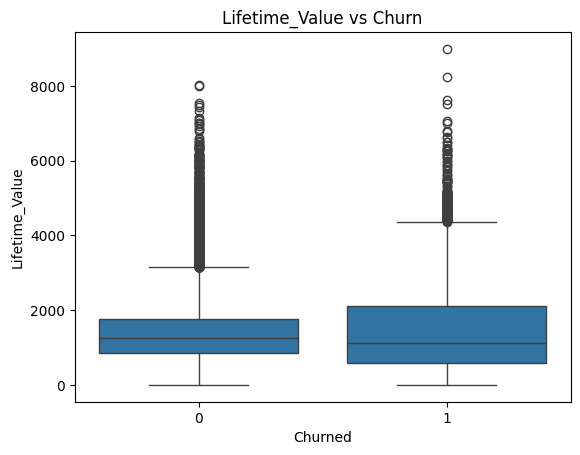

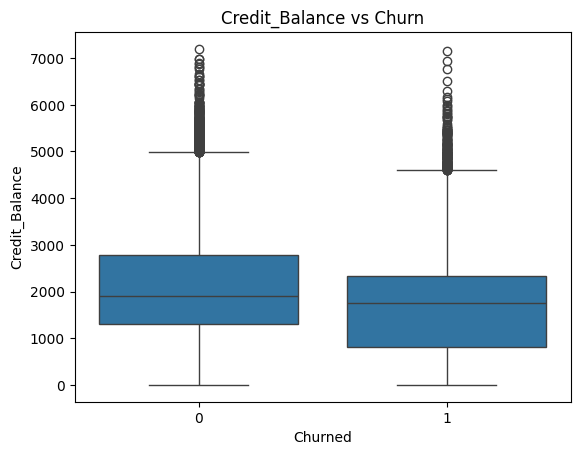

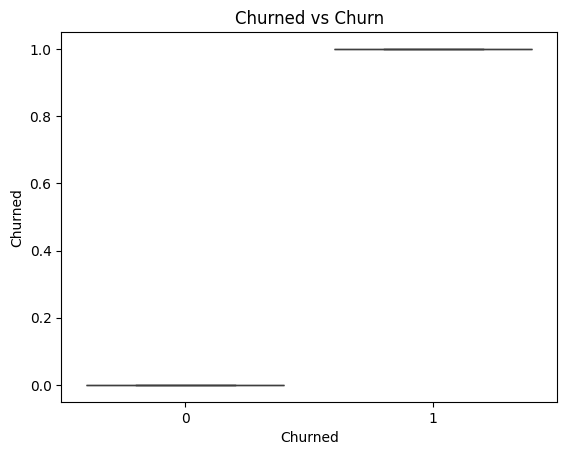

In [24]:
for col in num_cols:
    sns.boxplot(x='Churned', y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()


In [25]:
# checking the missing values count wheather is it filled or not
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            50000 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Membership_Years               50000 non-null  float64
 3   Login_Frequency                50000 non-null  float64
 4   Session_Duration_Avg           50000 non-null  float64
 5   Pages_Per_Session              50000 non-null  float64
 6   Cart_Abandonment_Rate          50000 non-null  float64
 7   Wishlist_Items                 50000 non-null  float64
 8   Total_Purchases                50000 non-null  float64
 9   Average_Order_Value            50000 non-null  float64
 10  Days_Since_Last_Purchase       50000 non-null  float64
 11  Discount_Usage_Rate            50000 non-null  float64
 12  Returns_Rate                   50000 non-null 

In [26]:
# removing the duplicates values
df.drop_duplicates(inplace=True)

In [27]:
df.head(5)

,Age,Gender,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
0,43.0,Male,2.9,14.0,27.4,6.0,50.6,3.0,9.0,94.72,...,2.0,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0
1,36.0,Male,1.6,15.0,42.7,10.3,37.7,1.0,19.5,82.45,...,9.2,42.8,7.0,3.0,27.6,23.3,3.0,1067.47,3028.0,0
2,45.0,Female,2.9,10.0,24.8,1.6,70.9,1.0,9.1,165.52,...,11.5,0.0,4.0,1.0,27.6,8.8,2.0,1289.75,2317.0,0
3,56.0,Female,2.6,10.0,38.4,14.8,41.7,9.0,15.0,147.33,...,5.4,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0
4,35.0,Male,3.1,29.0,51.4,8.4,19.1,9.0,32.5,141.30,...,5.5,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0


Define Features and Target

In [28]:
# Separate input features and target variable
X = df.drop("Churned", axis=1)
y = df["Churned"]

Splitting the data into train and test

In [29]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,stratify=y,random_state = 8)
print(X_train.shape)
print(X_test.shape)

(40000, 21)
(10000, 21)


 Data Preprocessing (Scaling + Encoding)

In [30]:
# ColumnTransformer for preprocessing
# Scale numerical features using RobustScaler
# Encode categorical feature (Gender)
from sklearn.preprocessing import RobustScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
numerical_cols=[0, 2, 3, 4, 5, 6, 7, 8, 9, 10,11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
categorical_cols=[1]
preprocessor = ColumnTransformer([
             ("Numerical",RobustScaler(),numerical_cols),
             ("Categorical",OneHotEncoder(),categorical_cols)],
             remainder="passthrough")

In [31]:
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('Numerical', RobustScaler(),
                                 [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14,
                                  15, 16, 17, 18, 19, 20]),
                                ('Categorical', OneHotEncoder(), [1])])

K-Nearest Neighbors classifier


In [32]:
# Build KNN pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
knn_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", KNeighborsClassifier())])

# Train KNN model
knn_pipeline.fit(X_train, y_train)

# Predictions
y_knn = knn_pipeline.predict(X_test)

Evaluation metrics

In [33]:
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy Score:",accuracy_score(y_knn, y_test))
print("\nClassification Report:\n")
print(classification_report(y_knn, y_test))


Accuracy Score: 0.8151

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.83      0.88      8071
           1       0.51      0.77      0.62      1929

    accuracy                           0.82     10000
   macro avg       0.73      0.80      0.75     10000
weighted avg       0.86      0.82      0.83     10000



Naive Bayes

In [34]:
# Build Naive Bayes pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline

nb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GaussianNB())
])

#Train Naive Bayes model
nb_pipeline.fit(X_train, y_train)

#Predictions
y_nb = nb_pipeline.predict(X_test)

 Evaluation metrics

In [35]:
# Import evaluation metrics to assess model performance
from sklearn.metrics import accuracy_score, classification_report

# Assign Naive Bayes predictions to y_pred for evaluation
y_pred = y_nb

# Print evaluation metrics
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.6674

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.69      0.75      7110
           1       0.45      0.62      0.52      2890

    accuracy                           0.67     10000
   macro avg       0.63      0.65      0.63     10000
weighted avg       0.71      0.67      0.68     10000



Decision Tree – Pipeline & Training


In [36]:
# Build Decision Tree pipeline
from sklearn.tree import DecisionTreeClassifier
dt_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=10, random_state=42))
])
model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
# Apply the preprocessor to transform X_train before fitting the model
X_train_processed = preprocessor.transform(X_train)
model.fit(X_train_processed, y_train)

DecisionTreeClassifier(max_depth=10, min_samples_split=5, random_state=42)

Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5]
}
grid = GridSearchCV(
    dt_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_final = best_model.predict(X_test)

Evaluation Metrics

In [ ]:
# Import evaluation metrics to assess model performance
from sklearn.metrics import accuracy_score, classification_report

# Print evaluation metrics
print("Best Accuracy:", accuracy_score(y_test, y_final))
print(classification_report(y_test, y_final))

logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Create the Logistic Regression pipeline
pipeline_lr = Pipeline([
    ('preprocessing', preprocessor),
    ('logistic', LogisticRegression(random_state=42, solver='liblinear'))
])

# Train Decision Tree model
pipeline_lr.fit(X_train, y_train)

# Predictions
y_lr = pipeline_lr.predict(X_test)

Evaluation Metrics


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Support Vector Classifier

In [ ]:
from sklearn.svm import SVC


In [ ]:
#built a svc pipeline
svc = SVC(
    probability=True,
    class_weight='balanced'
)
pipeline_svc = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('svc', svc)
])

# Train the svc pipeline
pipeline_svc.fit(X_train, y_train)

# Predictions
y_pred = pipeline_svc.predict(X_test)

Evaluation metrices

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Voting Classifier

In [ ]:
# build voting classifier model
from sklearn.ensemble import VotingClassifier
voting_clf = VotingClassifier(
    estimators=[
        ("lr", pipeline_lr),
        ("nb", nb_pipeline)
    ],
    voting="hard"
)

# Train the voting classifier
voting_clf.fit(X_train, y_train)

# Prediction
y_pred = voting_clf.predict(X_test)


Evaluation Metrics



In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Stacking Classifier

In [ ]:
# build a stacking classfier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC

In [ ]:
base_estimators = [
    ("lr", LogisticRegression(max_iter=3000)),
    ("nb", GaussianNB())
]
stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=3000),
    cv=5,
    n_jobs=-1
)

In [ ]:
#create a stacking_clf pipeline
from sklearn.pipeline import Pipeline

pipeline_stacking = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("stacking", stacking_clf)
])

# Train the voting classifier
pipeline_stacking.fit(X_train, y_train)

# Prediction
y_pred = pipeline_stacking.predict(X_test)

Evaluation Metrics



In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

RANDOM FOREST

In [ ]:
# build a randomforest pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("rf", RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

# train the random forest
rf_pipeline.fit(X_train, y_train)

# prediction
y_pred = rf_pipeline.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

All Boosting alogorithms

1.Adapative boosting

2.Gradient Boosting

3.Xtreame gradient boosting

In [ ]:
from sklearn.ensemble import (AdaBoostClassifier,GradientBoostingClassifier)
from xgboost import XGBClassifier

In [ ]:
#1.adaBoost
ada_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("ada", AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.5,
        random_state=42
    ))
])

 #2. Gradient Boosting
gb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("gb", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

# 3. XGBoost
xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("xgb", XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [ ]:
models = {
    "AdaBoost": ada_pipeline,
    "GradientBoosting": gb_pipeline,
    "XGBoost": xgb_pipeline}
for name, model in models.items():
    print(f"\n===== {name} =====")

In [ ]:
# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

In [ ]:
# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Among all the algorithms tested, Random Forest achieved the highest accuracy and consistent performance, making it the most reliable model for prediction.

Random Forest reduces overfitting by combining multiple decision trees, which improves generalization on unseen data compared to other algorithms.

It handles both numerical and categorical features effectively and provides stable results, which makes it suitable for real-time deployment using Streamlit.

Save Random Forest Model as Pickle (.pkl)

In [ ]:
import pickle

with open("random_forest_churn_model.pkl", "wb") as file:
    pickle.dump(rf_pipeline, file)

print("✅ Random Forest pickle file saved successfully")

Load Pickle File

In [ ]:
import pickle

with open("random_forest_churn_model.pkl", "rb") as file:
    rf_model_loaded = pickle.load(file)

print("✅ Model loaded successfully")

Conclusion:

In this project, multiple machine learning algorithms were evaluated to solve the prediction problem. Among them, the Random Forest algorithm achieved the best performance in terms of accuracy, stability, and generalization. Random Forest combines multiple decision trees, which helps in reducing overfitting and improving prediction reliability.

Because of its robustness and ability to handle both numerical and categorical features, Random Forest was selected for deployment. The trained model was integrated into a Streamlit web application, allowing users to provide input data and obtain real-time predictions. This deployment makes the model practical, user-friendly, and suitable for real-world usage.

Overall, Random Forest proved to be an effective and reliable choice for building and deploying the prediction system.